In [4]:
from utils import *
import numpy as np

t = 10000
N = 2 ** 32
alpha = 0.8

kis = [100] * t

def calculate_m0(N, t, alpha):  
    mttarget = (2 * N) / (t + 2)
    return (alpha * mttarget) / (1 - alpha)

m0 = calculate_m0(N, t, alpha)

tables = []


# for i in range(5):
#     table, rf_indexes, hashes, reductions, duration, m_vals = build_cherry_table(N, t, list(range(int(m0))), kis)
#     tables.append(m_vals)

for i in range(10):
    # read in from each directory the m_values and append to cherry_m_values
    # Assuming m_values are stored in a file named 'm_values_{i}.npy'
    m_values = np.load(f'../../naive-k-curves/const-k/n-32/trial_{i}/m_values.npy')
    tables.append(m_values)


# turn into dataframe
import pandas as pd
# each arrray of m_vals is a row in the dataframe
points_all_df = pd.DataFrame(tables)

In [5]:
# given N, K (list of number of RF trials per column), and starting m_0, approximate the m_i values for each column
def approximate_columns(N, K, m_0):
    m = m_0  # starting m value

    m_values = []  # store m values for each iteration
    m_values.append(m_0)

    # for the number of columns
    for k in K:
        # Calculate E1 and E2
        E1 = (1 - 1 / N) ** m
        E2 = (1 - 2 / N) ** m

        # calculate the statistical average of m_i
        average = N * (1 - E1)

        # find variance, and thus standard deviation
        if N * ((N - 1) * E2 + E1 - N * E1 ** 2) < 0:   # this equation gives the variance, so sqrt to get standard deviation
            # if it is negative (error), set it to 0
            sd = 0
        else:
            # count the statistical variance of m_i+1 otherwise
            sd = sqrt(N * ((N - 1) * E2 + E1 - N * E1 ** 2))

        # expectance of maximum of K samples 
        m = average + NormalDist().inv_cdf((k - pi / 8) / (k - pi / 4 + 1)) * sd
        m_values.append(m)

    return m_values


def approximate_columns_m(K, m_0):
    m = m_0  # starting m value

    m_values = []  # store m values for each iteration
    m_values.append(m_0)

    # for the number of columns
    for k in K:
        # Calculate E1 and E2
        E1 = (1 - 1 / m) ** m
        E2 = (1 - 2 / m) ** m

        # calculate the statistical average of m_i
        average = m * (1 - E1)

        # find variance, and thus standard deviation
        if m * ((m - 1) * E2 + E1 - m * E1 ** 2) < 0:   # this equation gives the variance, so sqrt to get standard deviation
            # if it is negative (error), set it to 0
            sd = 0
        else:
            # count the statistical variance of m_i+1 otherwise
            sd = sqrt(m * ((m - 1) * E2 + E1 - m * E1 ** 2))

        # expectance of maximum of K samples 
        m = average + NormalDist().inv_cdf((k - pi / 8) / (k - pi / 4 + 1)) * sd
        m_values.append(m)

    return m_values


# get mean
def get_mean_variance(m):
    # Calculate E1 and E2
    E1 = (1 - 1 / N) ** m
    E2 = (1 - 2 / N) ** m

    # calculate the statistical average of m_i
    average = N * (1 - E1)

    # find variance, and thus standard deviation
    if N * ((N - 1) * E2 + E1 - N * E1 ** 2) < 0:   # this equation gives the variance, so sqrt to get standard deviation
        # if it is negative (error), set it to 0
        var = 0
    else:
        # count the statistical variance of m_i+1 otherwise
        var = N * ((N - 1) * E2 + E1 - N * E1 ** 2)

    return average, var


def get_approximate_mi(average, k, sd):
    return average + NormalDist().inv_cdf((k - pi / 8) / (k - pi / 4 + 1)) * sd

In [6]:
## plot on cop model
#Imports
import os

import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
from math import sqrt, pi, log
from statistics import NormalDist


#Functions 

def calculate_m0(N, t, alpha):
    mttarget = (2 * N) / (t + 2)
    return (alpha * mttarget) / (1 - alpha)

def dp_matrix(N, m):

    """
    Returns an array of probabilites for each index number of bins to be occupied by m balls
    """

    # only store one array instead of a matrix, since we only need the previous row to calculate the current row
    prev = np.zeros(N + 1, dtype=np.float64)
    prev[0] = 1.0

    for i in range(1, m + 1):
        # next row
        curr = np.zeros(N + 1, dtype=np.float64)
        # for all bins
        j = np.arange(min(i, N) + 1)

        # if ball lands in a new bin (j > 0)
        # create an array of which elements of j are above 0
        # divide by N to get probabilities
        mask_new = j > 0
        curr[j[mask_new]] += prev[j[mask_new] - 1] * (N - (j[mask_new] - 1)) / N

        # if ball lands in existing bin (j <= i - 1)
        # create an array of which elements of j are less than or equal to i - 1
        # divide by N to get probabilities
        mask_existing = j <= i - 1
        curr[j[mask_existing]] += prev[j[mask_existing]] * j[mask_existing] / N

        # set prev to curr for next iteration
        prev = curr

    return prev[:min(m, N) + 1]


def dp_occupancy(N, m, j):
    matrix = dp_matrix(N, m)
    return matrix[j] if j < len(matrix) else 0.0


def dp_calc_max(N, m, k):
    matrix = dp_matrix(N, m)

    # Calculate CDFs using cumulative sum
    cdfs = np.cumsum(matrix)
    
    # Raise to power k
    cdf_powers = cdfs**k
    
    # Sum (1 - cdf^k) for y=0 to m
    return np.sum(1 - cdf_powers)

def table_cop(N, t, alpha, k_values):
    m0 = round(calculate_m0(N, t, alpha))
    m_values = [m0]
    m = m0

    for i in range(t):
        m = round(dp_calc_max(N, m, k_values[i]))
        m_values.append(m)

    return m_values

# m_values_cop = table_cop(N, t, 0.95, kis)


c:\Users\Mahfuzah Fariha\anaconda3\envs\choice_rf\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


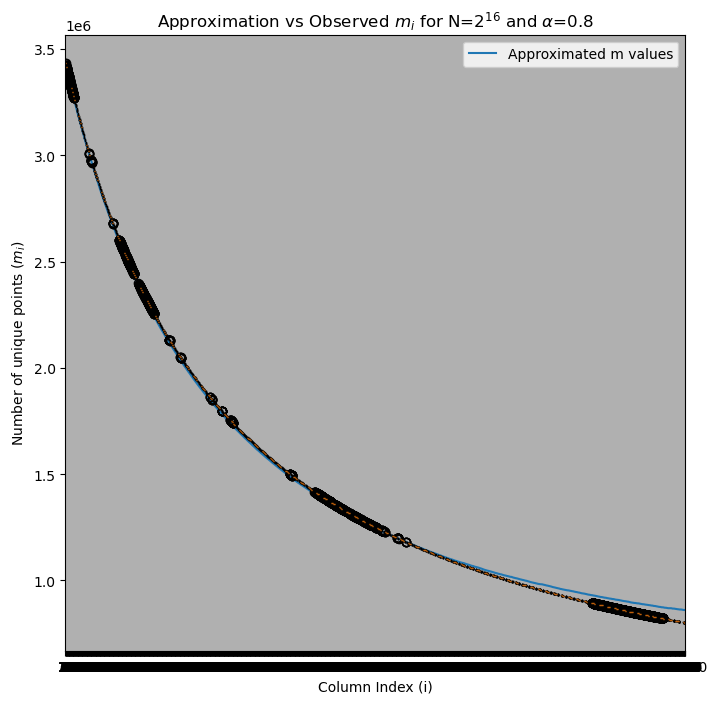

In [7]:
import matplotlib.pyplot as plt

## plot just alpha = 0.95
approximated_m_values = approximate_columns(N, kis, m0)
plt.figure(figsize=(8, 8))
plt.plot(approximated_m_values, label="Approximated m values")
# plot each column as a box plot - but start at 0 not 1
plt.boxplot(points_all_df.values, positions=range(len(points_all_df.columns)), widths=0.5)

# # plot m_values_cop
# plt.plot(m_values_cop, label="COP m values", linestyle="dashed")

plt.xlabel("Column Index (i)")
plt.ylabel(r"Number of unique points ($m_i$)")
plt.title(f"Approximation vs Observed $m_i$ for N=$2^{{16}}$ and $\\alpha$={alpha}")
# only show every 10 x-ticks
plt.xticks(ticks=range(0, len(kis)+1, 5), labels=range(0, len(kis)+1, 5))
plt.grid(True)
plt.legend() 
# save as eps and pdf
# plt.savefig(f"cherry_N_16_alpha_0.95_approximation_vs_actual.eps", format="eps")
# plt.savefig(f"cherry_N_16_alpha_0.95_approximation_vs_actual.pdf", format="pdf")   
plt.show()

In [8]:
# for alpha = 0.95

# get the approximated m values 
# approximated_m_values = approximate_columns(N, optimisation_kis[-1], calc_m0(N, t, alphas[-1]))

# Find the percent error of each sample compared to the approximation for each column and plot as a box plot
plt.figure(figsize=(8, 8))
# get the approximated m values 
approximated_m_values = approximate_columns(N, kis, m0)

# # Find the percent error of each sample compared to the approximation for each column and plot as a box plot
# # percent_errors_df = (points_df - approximated_m_values) / approximated_m_values * 100
# percent_errors_df = (points_df - approximated_m_values) / approximated_m_values * 100
# # Plot on the specific axis 'ax'
# plt.boxplot(percent_errors_df.values, positions=range(len(points_df.columns)), widths=0.6)

# plot on difference in cop model
percent_errors_cop = []
for i in range(len(m_values_cop)):
    percent_errors_cop.append((approximated_m_values[i] - m_values_cop[i]) / m_values_cop[i])

plt.plot(percent_errors_cop, label="Approximation percent error", linestyle="dashed")

plt.xlabel("Column Index (i)")
plt.ylabel("ratio")
# only show every 5 x-ticks
plt.xticks(ticks=range(0, t+1, 5), labels=range(0, t+1, 5))

plt.title(f"Error ratio of Approximation vs COP $m_i$ for N=$2^{{16}}$ and $\\alpha$={0.95}")
plt.grid(True)
plt.legend()    
# save as eps and pdf
plt.savefig(f"cherry_0.95_percent_error_approximation_vs_actual.eps", format="eps")
plt.savefig(f"cherry_0.95_percent_error_approximation_vs_actual.pdf", format="pdf")
plt.show()




NameError: name 'm_values_cop' is not defined

<Figure size 800x800 with 0 Axes>

C:\Users\psymf9\AppData\Local\Temp\ipykernel_23264\2041043301.py:32: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()
The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


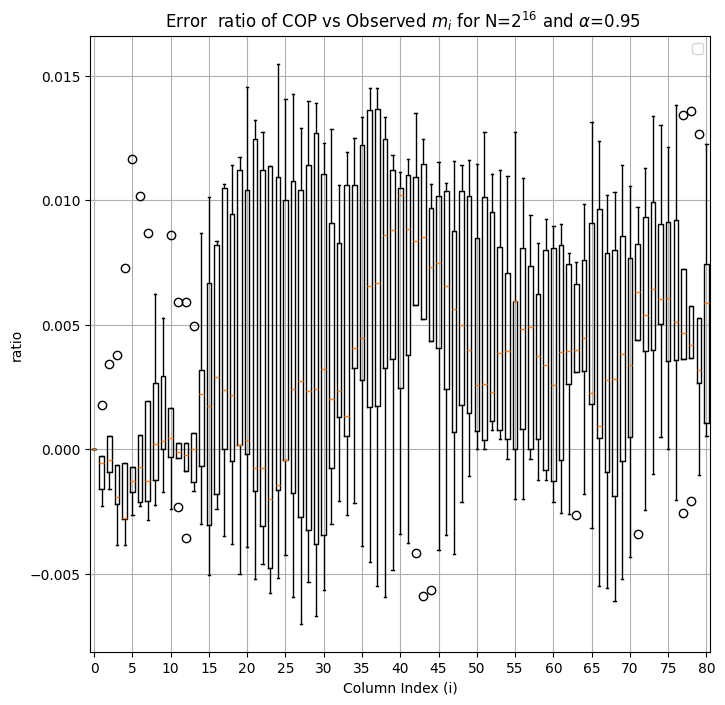

In [ ]:
# for alpha = 0.95


# get the approximated m values 
# approximated_m_values = approximate_columns(N, optimisation_kis[-1], calc_m0(N, t, alphas[-1]))

# Find the percent error of each sample compared to the approximation for each column and plot as a box plot
plt.figure(figsize=(8, 8))
# get the approximated m values 
approximated_m_values = approximate_columns(N, kis, m0)

# # Find the percent error of each sample compared to the approximation for each column and plot as a box plot
# percent_errors_df = (points_df - approximated_m_values) / approximated_m_values * 100
percent_errors_df = (points_all_df - m_values_cop) / m_values_cop 
# Plot on the specific axis 'ax'
plt.boxplot(percent_errors_df.values, positions=range(len(points_all_df.columns)), widths=0.6)

# # plot on difference in cop model
# percent_errors_cop = []
# for i in range(len(m_values_cop)):
#     percent_errors_cop.append((approximated_m_values[i] - m_values_cop[i]) / approximated_m_values[i] * 100)

# plt.plot(percent_errors_cop, label="COP percent error", linestyle="dashed")

plt.xlabel("Column Index (i)")
plt.ylabel("ratio")
# only show every 5 x-ticks
plt.xticks(ticks=range(0, t+1, 5), labels=range(0, t+1, 5))

plt.title(f" Error  ratio of COP vs Observed $m_i$ for N=$2^{{16}}$ and $\\alpha$={alpha}")
plt.grid(True)
plt.legend()    
# save as eps and pdf
plt.savefig(f"cherry_0.95_percent_error_approximation_vs_actual.eps", format="eps")
plt.savefig(f"cherry_0.95_percent_error_approximation_vs_actual.pdf", format="pdf")
plt.show()


